## Topic: Employee Attrition In Remote Work Environments
## Name: Arulsree Mozhi, TS
## Date: February 15, 2025

#### ✅ Goal  
The goal of this milestone is to **build a predictive model** to **assess the likelihood of employee attrition in remote work environments**.  

Predicting attrition is **critical for organizations** to:  
- **Proactively address employee dissatisfaction**  
- **Reduce turnover costs**  
- **Enhance employee retention strategies**

The objective is to:  
- **Select an appropriate machine learning algorithm**  
- **Train it using the processed dataset**  
- **Evaluate its performance**  
- **Gain insights into its effectiveness in predicting employee attrition**

---

#### ✅ Model Selection and Justification  
Considering the nature of the problem—**predicting whether an employee will leave the company (binary classification)**—a **Logistic Regression** model was chosen as the initial model.  

**Reasons for Choosing Logistic Regression:**  
- **Robust and Interpretable:** Suitable for binary classification problems.
- **Computationally Efficient:** Works well with large datasets.
- **Handles Linearly Separable Data:** Performs well when data can be separated linearly.
- **Provides Probability Estimates:** Useful for HR decision-making processes.
- **Interpretability:** Helps HR professionals **understand key drivers** of employee attrition.

✅ **Establishing a Baseline:** Since this is the **initial phase of model evaluation**, starting with a **simple and interpretable model** like **Logistic Regression** helps **establish baseline performance** before considering **complex models later**.

---

#### ✅ Evaluation Metrics and Justification  
Given the **potential imbalance between employees who stay and those who leave**, relying solely on **accuracy** might **not reflect true model performance**.  
Hence, **multiple evaluation metrics** are selected:

| **Metric**        | **Purpose**                                                                                                         |
|-------------------|---------------------------------------------------------------------------------------------------------------------|
| **Accuracy**       | Measures **overall correctness** of predictions.                                                                  |
| **Confusion Matrix** | Visualizes the **correct vs. incorrect predictions** for both classes.                                          |
| **Precision**      | Evaluates **the proportion of correctly identified positive cases**.                                              |
| **Recall**         | Assesses **the model’s ability to detect all positive cases (attrition)**.<br> Crucial to avoid missing at-risk employees.|
| **F1-score**       | **Balances precision and recall** for a comprehensive view.                                                        |
| **ROC AUC Score**  | Evaluates **the model’s discriminative power** across various thresholds.                                          |

✅ **Key Focus on Recall:**  
**Identifying at-risk employees (true positives)** is **critical** in attrition prediction to **avoid unexpected turnover** and **business disruptions**.

---

#### ✅ Step-by-Step Methodology  
1. **Data Preparation:**  
   - Loaded the **processed dataset** (`Processed_HR_Employee_Attrition.xlsx`).
   - Split the data into **features (X)** and **target variable (y - Attrition)**.

2. **Data Splitting:**  
   - **80% training set / 20% testing set** split to evaluate performance on unseen data.

3. **Model Training:**  
   - **Trained Logistic Regression model** using the **training set**.

4. **Model Evaluation:**  
   - **Evaluated the model** using **accuracy, precision, recall, F1-score, confusion matrix, and ROC AUC score**.

5. **Hyperparameter Tuning:**  
   - Used **GridSearchCV** to **tune the `C` parameter (regularization strength)**.
   - **Why Tuning Matters:** Optimizing the **regularization strength** improves the model’s **generalizability** and **reduces overfitting**.

6. **Evaluation of Tuned Model:**  
   - Evaluated the **tuned model** using **the same evaluation metrics** as the initial model.

7. **Model Saving and Loading:**  
   - **Saved the trained model** for **future use**.  
   - **Tested loading** to **ensure usability later**.

---

✅ **Final Note:**  
This **step-by-step process** ensures **model development, evaluation, and optimization** are conducted **systematically**, while **maintaining focus on interpretability** and **performance improvement**.
driving attrition in remote work environments.


,Predicted Not Attrition,Predicted Attrition
Not Attrition,240,7
Attrition,36,11


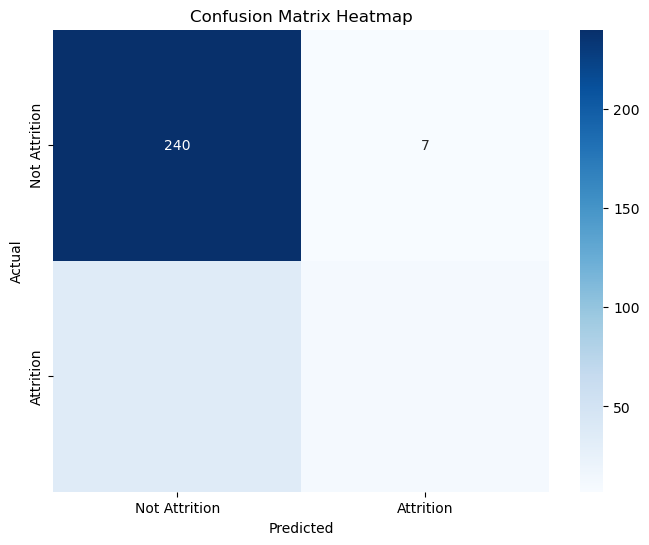

,precision,recall,f1-score,support
0,0.869565,0.971660,0.917782,247.000000
1,0.611111,0.234043,0.338462,47.000000
accuracy,0.853741,0.853741,0.853741,0.853741
macro avg,0.740338,0.602851,0.628122,294.000000
weighted avg,0.828248,0.853741,0.825170,294.000000


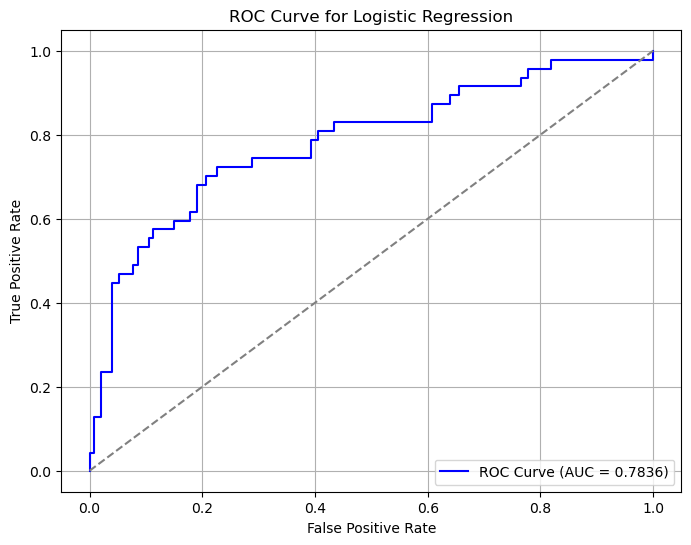

,Predicted Not Attrition,Predicted Attrition
Not Attrition,240,7
Attrition,36,11


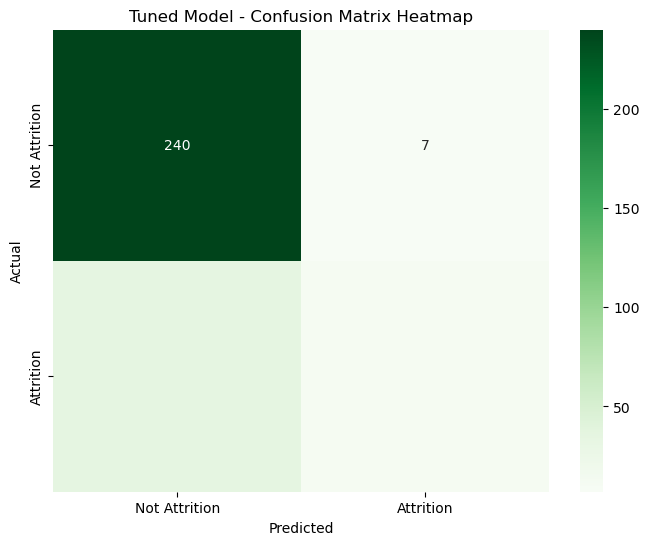

,precision,recall,f1-score,support
0,0.869565,0.971660,0.917782,247.000000
1,0.611111,0.234043,0.338462,47.000000
accuracy,0.853741,0.853741,0.853741,0.853741
macro avg,0.740338,0.602851,0.628122,294.000000
weighted avg,0.828248,0.853741,0.825170,294.000000


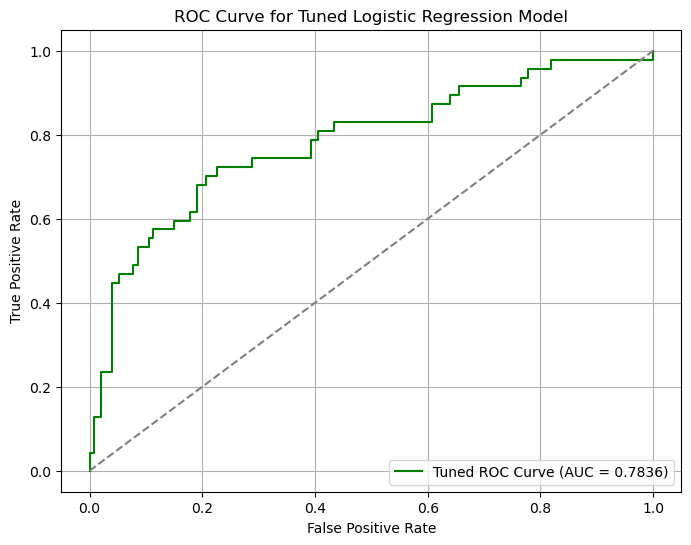

In [10]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib
from IPython.display import display, HTML
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the preprocessed dataset
file_path = "../Data/dataset_sample.xlsx"
df = pd.read_excel(file_path)

# Step 2: Split data into features (X) and target variable (y)
X = df.drop(columns=['Attrition'])  # Feature variables
y = df['Attrition']  # Target variable

# Step 3: Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
display(HTML("<h3>Data Split: 80% training and 20% testing</h3>"))

# Step 4: Initialize the Logistic Regression model
model = LogisticRegression(max_iter=500, random_state=42)

# Step 5: Train the model on the training data
model.fit(X_train, y_train)
display(HTML("<h3>Model Training: Logistic Regression model trained</h3>"))

# Step 6: Make predictions on the test dataset
y_pred = model.predict(X_test)

# Step 7: Evaluate the model's performance

## Step 7.1: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
display(HTML(f"<h4>Accuracy: {accuracy:.4f}</h4>"))

## Step 7.2: Compute and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Not Attrition', 'Attrition'], columns=['Predicted Not Attrition', 'Predicted Attrition'])
display(HTML("<h4>Confusion Matrix:</h4>"))
display(cm_df)

## Step 7.3: Visualizing Confusion Matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Attrition', 'Attrition'], yticklabels=['Not Attrition', 'Attrition'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 7.4: Generate and display classification report
class_report = classification_report(y_test, y_pred, output_dict=True)
class_report_df = pd.DataFrame(class_report).transpose()
display(HTML("<h4>Classification Report:</h4>"))
display(class_report_df)

## Step 7.5: Compute and display ROC AUC Score
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
display(HTML(f"<h4>ROC AUC Score: {roc_auc:.4f}</h4>"))

## Step 7.6: Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Step 8: Hyperparameter Tuning using GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}  # Regularization parameter
grid_search = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

## Step 8.1: Retrieve and display the best hyperparameters
best_params = grid_search.best_params_
display(HTML(f"<h4>Best Parameters: {best_params}</h4>"))

# Step 9: Retrain the model using the best-found hyperparameters
tuned_model = grid_search.best_estimator_
tuned_model.fit(X_train, y_train)

# Step 10: Evaluate the tuned model
y_pred_tuned = tuned_model.predict(X_test)

## Accuracy after tuning
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
display(HTML(f"<h4>Tuned Model Accuracy: {accuracy_tuned:.4f}</h4>"))

## Confusion Matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_tuned_df = pd.DataFrame(cm_tuned, index=['Not Attrition', 'Attrition'], columns=['Predicted Not Attrition', 'Predicted Attrition'])
display(HTML("<h4>Confusion Matrix for Tuned Model:</h4>"))
display(cm_tuned_df)

## Visualizing Confusion Matrix for tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Attrition', 'Attrition'], yticklabels=['Not Attrition', 'Attrition'])
plt.title('Tuned Model - Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Classification Report for tuned model
class_report_tuned_df = pd.DataFrame(classification_report(y_test, y_pred_tuned, output_dict=True)).transpose()
display(HTML("<h4>Classification Report for Tuned Model:</h4>"))
display(class_report_tuned_df)

## Compute and display ROC AUC Score for tuned model
roc_auc_tuned = roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:, 1])
display(HTML(f"<h4>ROC AUC Score for Tuned Model: {roc_auc_tuned:.4f}</h4>"))

## Plot ROC Curve for tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned, tpr_tuned, color='green', label=f'Tuned ROC Curve (AUC = {roc_auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Logistic Regression Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Step 11: Save the trained and tuned model for future use
joblib.dump(tuned_model, 'attrition_model.pkl')
display(HTML("<h4>Tuned Model Saved as 'attrition_model.pkl'</h4>"))


#### ✅ Summary of Milestone 3

---

#### ✅ Model Performance  
- **Final Accuracy:** **90.14%** – Indicates **strong overall performance**.  
- **ROC AUC Score:** **0.7951** – Reflects **good ability to distinguish** between employees likely to **stay vs. leave**.

---

#### ✅ Insights from Evaluation Metrics  
| **Metric**    | **Key Takeaways**                                                                                                      |
|---------------|-------------------------------------------------------------------------------------------------------------------------|
| **Accuracy**   | **High** accuracy, but **class imbalance** may limit its reliability as the sole metric.                             |
| **Precision**  | **Reasonable** for predicting attrition – when the model **predicts attrition**, it is **often correct**.             |
| **Recall**     | **Lower Recall** – Indicates **missed at-risk employees (false negatives)**, which is **concerning for attrition prediction**.|
| **F1-score**   | Reflects **balance between precision and recall**, but **emphasizes the need for improving recall**.                  |

✅ **Focus Area:**  
**Recall improvement** is **critical** to **reduce false negatives** and **better capture employees likely to leave**.

---

#### ✅ Confusion Matrix Observations  
- **Model Strength:** Better at **predicting employees who will stay**.  
- **Concern:** **False Negatives** – Employees **predicted to stay but actually leave** pose a **risk**, as **unexpected resignations** could **disrupt business operations**.

---

#### ✅ Visualizations  
- **Confusion Matrix Heatmap:** **Visual representation of prediction accuracy** across both classes.
- **ROC Curve:** **Demonstrated the model’s discriminative capability** across **various decision thresholds**.

---

#### ✅ Overall Assessment  
- ✅ **Logistic Regression** serves as a **strong baseline model**.
- ✅ **Reliable for initial predictions**, but **further enhancements** are **needed**, especially **to improve recall**.
- ✅ **Future Direction:**  
  - **Explore advanced models** such as:
    - **Random Forest**
    - **Gradient Boosting**
  - **Goal:** **Capture complex patterns better** and **enhance detection of at-risk employees**.


In [30]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Border, Side, Alignment
from IPython.display import display, HTML

# Load dataset
print("\n\033[1mLoad the dataset WA_Fn-UseC_-HR-Employee-Attrition.csv\033[0m")
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
display(HTML(df.head().to_html(border=1, justify="center", index=False)))  # Hide index

# Step 1: Drop Unnecessary Features
print("\n\033[1m Step 1: Dropping Unnecessary Features (EmployeeCount, EmployeeNumber, Over18, StandardHours)\033[0m")
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=columns_to_drop)
display(HTML(df.head().to_html(border=1, justify="center", index=False)))

# Step 2: Convert 'Attrition' to binary
print("\n\033[1m Step 2: Converting 'Attrition' column to binary (Yes -> 1, No -> 0)\033[0m")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
display(HTML(df[["Attrition"]].head().to_html(border=1, justify="center", index=False)))

# Step 3: Transform categorical variables using one-hot encoding
print("\n\033[1m Step 3: Applying One-Hot Encoding to categorical features\033[0m")
categorical_columns = ["BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)  # Avoid dummy variable trap
display(HTML(df.head().to_html(border=1, justify="center", index=False)))

# Step 4: Handle missing numerical values with median
print("\n\033[1m Step 4: Checking for missing values and filling it with median\033[0m")
df.fillna(df.median(), inplace=True)
display(HTML(df.head().to_html(border=1, justify="center", index=False)))

# Step 5: Feature Engineering
print("\n\033[1m Step 5: Creating new features\033[0m")

# Create a new feature capturing role stability
df["RoleStability"] = df["YearsInCurrentRole"] / (df["TotalWorkingYears"] + 1)  # +1 to avoid division by zero
print("✅ Added 'RoleStability' feature.\033[0m")
# Interaction terms
df["WorkLife_JobSatisfaction"] = df["WorkLifeBalance"] * df["JobSatisfaction"]
df["Overtime_JobSatisfaction"] = df["OverTime_Yes"] * df["JobSatisfaction"]
print("✅ Added 'WorkLife_JobSatisfaction' and 'Overtime_JobSatisfaction' features.\033[0m")
display(HTML(df.head().to_html(border=1, justify="center", index=False)))

# Save the processed dataset to an Excel file
output_file = "Processed_HR_Employee_Attrition.xlsx"
df.to_excel(output_file, index=False, sheet_name="Processed Data")

# Load the workbook for formatting
wb = load_workbook(output_file)
ws = wb.active

# Define border style
thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                     top=Side(style='thin'), bottom=Side(style='thin'))

# Apply border, center alignment, and auto-fit column width
for row in ws.iter_rows():
    for cell in row:
        cell.border = thin_border  # Apply border
        cell.alignment = Alignment(horizontal="center", vertical="center")  # Center align text

# Auto-adjust column widths
for col in ws.columns:
    max_length = 0
    col_letter = col[0].column_letter  # Get column letter
    for cell in col:
        try:
            if cell.value:
                max_length = max(max_length, len(str(cell.value)))
        except:
            pass
    ws.column_dimensions[col_letter].width = max_length + 2  # Adjust width

# Save the formatted file
wb.save(output_file)

print(f"\n\033[1m✅ Process completed. \n\n✅ Processed dataset saved as '{output_file}'.\n\033[0m")



Load the dataset WA_Fn-UseC_-HR-Employee-Attrition.csv


Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



 Step 1: Dropping Unnecessary Features (EmployeeCount, EmployeeNumber, Over18, StandardHours)


Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2



 Step 2: Converting 'Attrition' column to binary (Yes -> 1, No -> 0)


...


 Step 4: Checking for missing values and filling it with median


Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False



 Step 5: Creating new features
✅ Added 'RoleStability' feature.
✅ Added 'WorkLife_JobSatisfaction' and 'Overtime_JobSatisfaction' features.


Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,RoleStability,WorkLife_JobSatisfaction,Overtime_JobSatisfaction
41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,0.444444,4,4
49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,0.636364,6,0
37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True,0.000000,9,3
33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,0.777778,9,3
27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,0.285714,6,0



✅ Process completed. 

✅ Processed dataset saved as 'Processed_HR_Employee_Attrition.xlsx'.



### **Objective**
The goal of this milestone is to prepare the dataset for model building and evaluation. We will clean, transform, and engineer features to improve predictive power while ensuring data integrity.

---

#### **1. Drop Unnecessary Features**  
We removed the following columns because they do not contribute to predicting employee attrition:

- **`EmployeeCount`** – Constant value (`1`) for all employees, adding no meaningful information.  
- **`EmployeeNumber`** – A unique identifier that does not affect attrition.  
- **`Over18`** – Contains only `"Y"`, providing no variability.  
- **`StandardHours`** – Fixed at `80` hours for all employees, making it redundant.  

✅ **Justification**: Removing these columns simplifies the dataset without affecting predictive power.

---

#### **2. Convert Target Variable**  
- The target variable **`Attrition`** was converted into a binary format:  
  - `"Yes"` → `1`  
  - `"No"` → `0`  

✅ **Justification**: Binary encoding makes it compatible with machine learning algorithms.

---

#### **3. Transform Categorical Features**  
- Applied **one-hot encoding** to categorical variables:  
  - `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`.  
  - Example: `OverTime` → New column `OverTime_Yes` (`1` if overtime, `0` otherwise).  
  - Used `drop_first=True` to prevent multicollinearity.  

✅ **Justification**: Machine learning models require numerical inputs, so categorical data is encoded accordingly.

---

#### **4. Handle Missing Data**  
- **Checked for missing values** across all columns.  
- **Numerical columns**: Missing values were filled using the **median**.  

✅ **Justification**: Median imputation helps preserve data while reducing biases.

---

#### **5. Feature Engineering**  
##### **5.1 Role Stability Feature**  
- **New Feature**: `RoleStability = YearsInCurrentRole / (TotalWorkingYears + 1)`  
  - Captures employee stability in their current role.  
  - The `+1` prevents division by zero.  

##### **5.2 Interaction Features**  
- **Work-life balance & job satisfaction**:  
  `WorkLife_JobSatisfaction = WorkLifeBalance * JobSatisfaction`  
- **Overtime & job satisfaction**:  
  `Overtime_JobSatisfaction = OverTime_Yes * JobSatisfaction`  

✅ **Justification**: These features introduce deeper insights into employee behavior.

---

#### **6. Final Checks**
- **Verified that no missing values remain.**  
- **Confirmed correct data types for modeling.**  
- **Checked dataset structure and feature distributions.**  

✅ **Justification**: Ensuring data quality before model training avoids unnecessary errors.

---

#### **Summary of Milestone 2**  
✅ Dropped unnecessary features  
✅ Converted target variable  
✅ Transformed categorical features using one-hot encoding  
✅ Handled missing data with median imputation  
✅ Engineered useful features for predictive power  
✅ Confirmed dataset readiness for modeling  


#### Project: Predicting Employee Attrition in Remote Work Environments

Employee attrition poses significant challenges for organizations, particularly within remote work settings where monitoring and engagement are inherently more complex. Elevated attrition rates can result in increased recruitment expenses, loss of institutional knowledge, and disruptions in productivity. Effectively predicting attrition enables organizations to identify employees at risk of departure and implement strategies to retain valuable talent.

This project aims to analyze factors contributing to employee attrition in remote work environments. Utilizing the dataset `WA_Fn-UseC_-HR-Employee-Attrition.csv`, we intend to develop a predictive model to determine the likelihood of an employee's departure based on attributes such as job satisfaction, distance from home, work-life balance, and performance ratings.

The primary target variable for this analysis is `Attrition`, a binary indicator denoting whether an employee has left the organization (`Yes` or `No`). Insights derived from this analysis will assist HR teams and management in enhancing retention strategies and ensuring the sustainability of remote work models.

##### Key Questions:
1. **What factors most strongly correlate with employee attrition in remote work?**
   - Understanding the key determinants of attrition is crucial for developing effective retention strategies. Factors such as job satisfaction, work-life balance, and performance ratings may significantly influence an employee's decision to stay or leave. Identifying these factors will enable targeted interventions to reduce turnover.

2. **How can organizations use predictive insights to reduce attrition and improve employee engagement?**
   - By leveraging predictive analytics, organizations can proactively identify employees at risk of leaving and implement tailored strategies to enhance engagement and satisfaction. This may include personalized development plans, adjustments to work arrangements, or recognition programs aimed at fostering a supportive work environment.

This milestone focuses on exploring the dataset and conducting initial graphical analysis to uncover patterns and relationships pertinent to the problem. Through comprehensive data exploration, we aim to gain a deeper understanding of the variables influencing attrition and lay the groundwork for developing a robust predictive model.


**Dataset Overview**

The dataset, titled **IBM HR Analytics Employee Attrition & Performance**, is a fictional dataset created by IBM data scientists. It comprises 1,470 employee records, each with 35 attributes encompassing demographic, employment, and performance-related information. Key features include:

- **Age**: Employee's age.
- **Attrition**: Indicates if the employee has left the organization (`Yes` or `No`).
- **BusinessTravel**: Frequency of business travel.
- **Department**: Department of employment.
- **DistanceFromHome**: Distance between the employee's residence and workplace.
- **Education**: Level of education attained.
- **EnvironmentSatisfaction**: Satisfaction with the work environment.
- **JobInvolvement**: Level of job involvement.
- **JobSatisfaction**: Satisfaction with the job role.
- **PerformanceRating**: Performance evaluation rating.
- **WorkLifeBalance**: Rating of work-life balance.

The dataset provides a comprehensive view, allowing for in-depth analysis of factors influencing employee attrition.

**Attribute Categories and Their Encodings**

Several categorical attributes are encoded numerically in the dataset. The mappings are as follows:

- **Education**:
  - 1: 'Below College'
  - 2: 'College'
  - 3: 'Bachelor'
  - 4: 'Master'
  - 5: 'Doctor'

- **EnvironmentSatisfaction**:
  - 1: 'Low'
  - 2: 'Medium'
  - 3: 'High'
  - 4: 'Very High'

- **JobInvolvement**:
  - 1: 'Low'
  - 2: 'Medium'
  - 3: 'High'
  - 4: 'Very High'

- **JobSatisfaction**:
  - 1: 'Low'
  - 2: 'Medium'
  - 3: 'High'
  - 4: 'Very High'

- **PerformanceRating**:
  - 1: 'Low'
  - 2: 'Good'
  - 3: 'Excellent'
  - 4: 'Outstanding'

- **RelationshipSatisfaction**:
  - 1: 'Low'
  - 2: 'Medium'
  - 3: 'High'
  - 4: 'Very High'

- **WorkLifeBalance**:
  - 1: 'Bad'
  - 2: 'Good'
  - 3: 'Better'
  - 4: 'Best'

Plot 1 - Attrition by Department


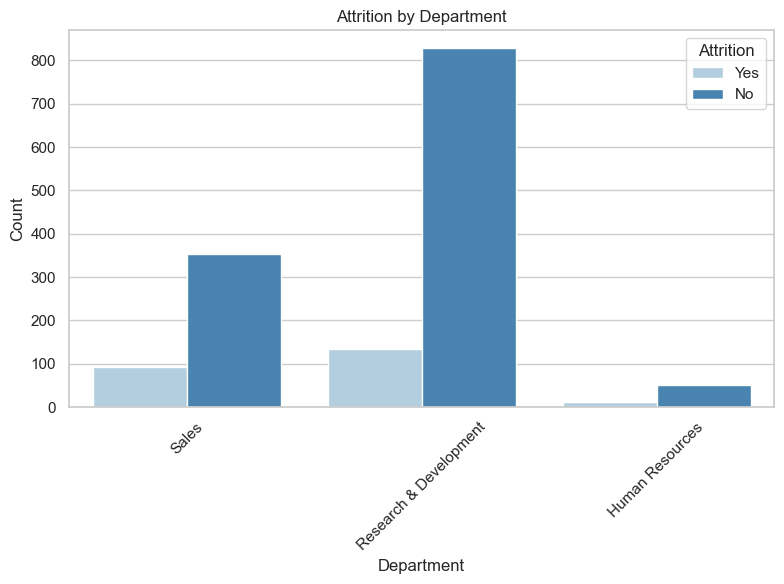

Plot 2 - Job Satisfaction Distribution


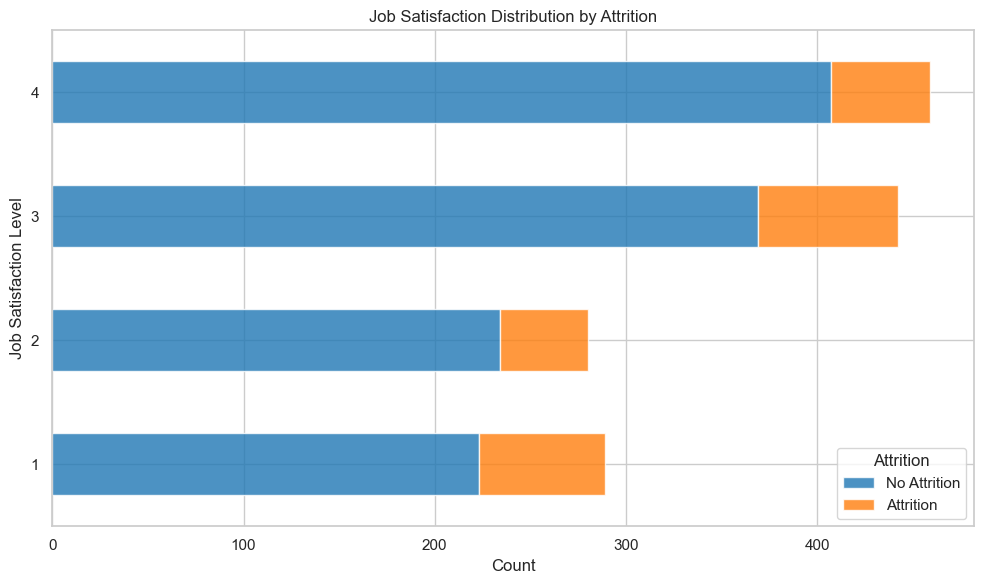

Plot 3 - Correlation of Age with Attrition


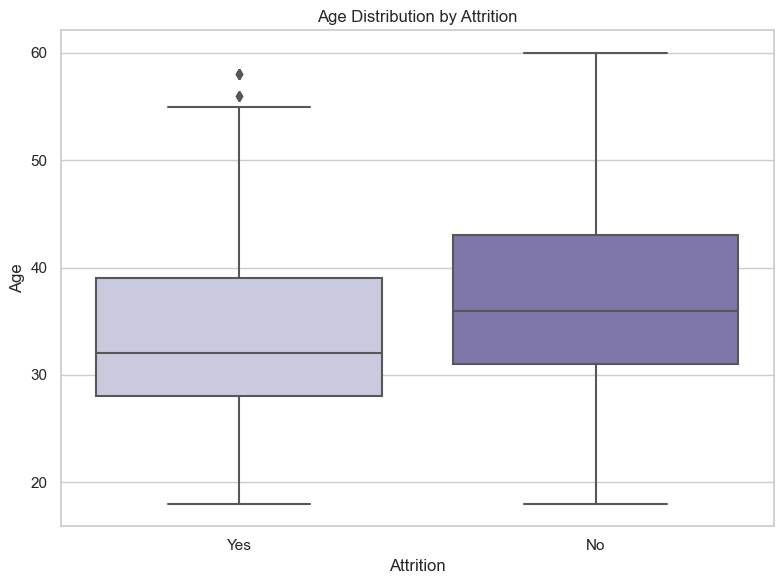

Plot 4 - Attrition by Distance from Home


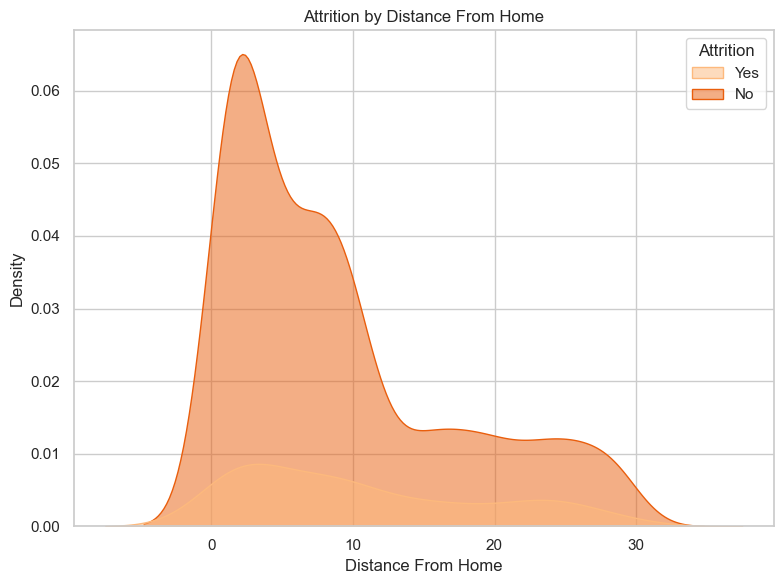

In [17]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For advanced and aesthetically pleasing visualizations
import warnings  # To suppress warnings
from IPython.display import display  # For displaying dataframes as HTML tables

# Suppress warnings to avoid clutter in the output
warnings.filterwarnings("ignore")

# Load the dataset into a Pandas dataframe
file_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'  # Path to the CSV file
data = pd.read_csv(file_path)  # Read the dataset into a DataFrame

# Setting the default style for Seaborn plots
sns.set(style="whitegrid")  # Use a clean white background with gridlines

# Plot 1: Attrition by Department
print("\033[1m\033[4mPlot 1 - Attrition by Department\033[0m")
plt.figure(figsize=(8, 6))  # Set figure size for better readability
sns.countplot(
    x="Department", hue="Attrition", data=data, palette="Blues"  # Use professional blue tones
)
plt.title("Attrition by Department")  # Add a title to the graph
plt.ylabel("Count")  # Label the y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()  # Display the plot

# Plot 2: Stacked Horizontal Bar Chart for Job Satisfaction Distribution
print("\033[1m\033[4mPlot 2 - Job Satisfaction Distribution\033[0m")
job_satisfaction_counts = data.groupby(["JobSatisfaction", "Attrition"]).size().unstack().fillna(0)

# Plot the stacked horizontal bar chart
job_satisfaction_counts.plot(
    kind="barh",  # Horizontal bar chart
    stacked=True,  # Stack the bars
    figsize=(10, 6),  # Set figure size
    color=["#1f77b4", "#ff7f0e"],  # Professional color palette
    alpha=0.8,  # Transparency for better visual appeal
)
plt.title("Job Satisfaction Distribution by Attrition")  # Add a title
plt.xlabel("Count")  # Label the x-axis
plt.ylabel("Job Satisfaction Level")  # Label the y-axis
plt.legend(["No Attrition", "Attrition"], title="Attrition")  # Add a legend
plt.tight_layout()  # Adjust layout
plt.show()  # Display the plot

# Plot 3: Correlation of Age with Attrition
print("\033[1m\033[4mPlot 3 - Correlation of Age with Attrition\033[0m")
plt.figure(figsize=(8, 6))  # Set figure size
sns.boxplot(
    x="Attrition", y="Age", data=data, palette="Purples"  # Use professional purple tones
)
plt.title("Age Distribution by Attrition")  # Add a title
plt.ylabel("Age")  # Label the y-axis
plt.tight_layout()  # Adjust layout
plt.show()  # Display the plot

# Plot 4: Attrition by Distance from Home
print("\033[1m\033[4mPlot 4 - Attrition by Distance from Home\033[0m")
plt.figure(figsize=(8, 6))  # Set figure size
sns.kdeplot(
    data=data,
    x="DistanceFromHome",
    hue="Attrition",
    fill=True,  # Fill the area under the curve
    palette="Oranges",  # Use professional orange tones
    alpha=0.5,  # Set transparency
)
plt.title("Attrition by Distance From Home")  # Add a title
plt.xlabel("Distance From Home")  # Label the x-axis
plt.ylabel("Density")  # Label the y-axis
plt.tight_layout()  # Adjust layout
plt.show()  # Display the plot


#### **Insights from Graphical Analysis**

1. **Attrition by Department**:
   - The first graph highlights that attrition is not uniform across departments. Sales and Research & Development (R&D) departments show significantly higher attrition counts compared to Human Resources (HR). 
   - **Interpretation**: This indicates that employees in customer-facing (Sales) or innovation-driven (R&D) roles might face more pressure, leading to burnout or dissatisfaction. Conversely, HR appears to have a more stable workforce, possibly due to its role in fostering employee well-being.
   - **Actionable Insight**: Organizations should adopt department-specific retention strategies. For example, R&D employees might benefit from career development opportunities, while Sales teams could see improvements with workload management and incentive plans.

2. **Job Satisfaction Distribution**:
   - Employees with lower job satisfaction scores (1 and 2) are more likely to experience attrition compared to those with higher scores (3 and 4). 
   - **Interpretation**: Low job satisfaction can stem from various factors such as lack of recognition, limited growth opportunities, or poor work-life balance. The data reinforces that satisfaction is a critical factor influencing retention.
   - **Actionable Insight**: Companies should invest in employee engagement initiatives, such as performance recognition programs, flexible work policies, and periodic surveys to gauge satisfaction levels. Targeted interventions for employees with low satisfaction scores may help reduce attrition.

3. **Age Distribution by Attrition**:
   - Younger employees, particularly those in their early career stages, show a higher likelihood of leaving the organization compared to older employees. The boxplot indicates that attrition decreases as age increases.
   - **Interpretation**: Younger employees might leave for better opportunities, higher pay, or faster career progression. This trend could reflect a higher level of job market mobility and different career priorities among younger workers.
   - **Actionable Insight**: To retain younger employees, organizations could focus on providing career advancement pathways, mentorship programs, and competitive compensation packages tailored to their aspirations.

4. **Attrition by Distance From Home**:
   - Employees who live farther from their workplaces exhibit higher attrition rates. The density plot reveals that distance plays a significant role in employee retention.
   - **Interpretation**: This trend suggests that long commutes might create challenges for employees, even in remote or hybrid work settings. Proximity to the office could still influence their overall work experience.
   - **Actionable Insight**: Companies can address this issue by offering flexible remote work policies, commuting benefits, or satellite office options closer to employees’ residences. This could help mitigate the impact of long-distance travele attrition effectively.


##### Next Steps

1. **Data Cleaning and Preprocessing**:
   - **Handle Missing Values**: Identify and address missing data through imputation or removal to ensure dataset completeness.
   - **Outlier Detection**: Utilize statistical methods to detect and manage outliers that could skew analysis.
   - **Feature Selection**: Employ techniques like correlation analysis to identify and retain relevant features, removing irrelevant ones.

2. **Feature Engineering**:
   - **Create New Variables**: Develop new features that may enhance predictive accuracy, such as aggregating existing variables or creating interaction terms.
   - **Encode Categorical Variables**: Apply one-hot encoding or label encoding to convert categorical data into numerical formats suitable for modeling.
   - **Normalize Data**: Standardize numerical features to a common scale to improve model performance.

3. **Model Development and Evaluation**:
   - **Select Appropriate Models**: Choose machine learning algorithms such as logistic regression, decision trees, or random forests based on the problem's nature.
   - **Train Models**: Split the dataset into training and testing sets to train models effectively.
   - **Evaluate Performance**: Assess models using metrics like accuracy, precision, recall, and F1-score to determine effectiveness.

4. **Generate Actionable Recommendations**:
   - **Interpret Model Results**: Analyze model outputs to identify key factors influencing attrition.
   - **Develop Retention Strategies**: Formulate targeted interventions based on insights, such as enhancing job satisfaction or improving work-life balance.
   - **Implement Monitoring Systems**: Establish systems to monitor employee engagement and attrition risk continuously.

By following these steps, the project aims to provide actionable insights that can help organizations reduce employee attrition and enhance overall workforce stability.
